# Polynomial regression

In this notebook, we demonstrate how to predict seismic velocities at unknown depths using polynomial regression on an observed velocity–depth well-log catalog.

## Science Question: Estimating seismic velocity with depth

Seismic velocity measurements typically increase with depth, driven by compaction, increasing overburden pressure, and porosity reduction, but the relationship is often nonlinear due to lithology changes and local seismic discontinuities.

A common empirical form for the near-surface (depths < 10 km) is $V(z) = V_0 + \sum_1^n k_i\,z^{n}$ (e.g., see Table 1 in Wang and Wang, 2016). Since the relationship between the independent variable $z$, depth, and dependent variable $V$, seismic velocity, is often not linear, $n>1$, we  use polynomial regression to model the relationship.

## Machine Learning Technique

Similar to linear regression, polynomial regression is a form of regression analysis in which the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial.

Assuming, we have a given set of points, $x_i, y_i$, and we want to fit a polynomial of degree $d$ to these points, we can express the model as:

\begin{equation}
    y = \beta_0 + \beta_1 x + \beta_2 x^2 + ... + \beta_d x^d + \epsilon
\end{equation}

where, $\beta_0, \beta_1, ..., \beta_d$ are the coefficients of the polynomial and $\epsilon$ added to account for the random measurement error.

### Analytical form
Although, $y$ depends non-linearly on $x$ in equation (1), the model is linear in the coefficients $\beta_0, \beta_1, ..., \beta_d$. Therefore, we can solve for the coefficients similar to linear regression using the least squares method.

In matrix form:
  $$ \mathbf{y} = \mathbf{X} \boldsymbol{\beta} + \boldsymbol{\epsilon} $$

Here, $y$ is $n \times 1$ vector of observations, $\beta =(\beta_0,…,\beta_d)^T $ is the ($(d+1) \times 1$) vector of unknown coefficients, and X is the $(n \times (d+1))$ design matrix:
$$
\mathbf{X} = \begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & \cdots & x_2^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^d
\end{bmatrix}
$$

where each row corresponds to a data point and each column corresponds to a power of $x$.


The least squares solution for $\beta$ is given by:

\begin{equation}
  f(\boldsymbol\beta) = \sum_{i=1}^{n} \left(y_i - \sum_{j=0}^{d} \beta_j x_i^j\right)^2 = \left \| \mathbf{y} - \mathbf{X} \boldsymbol{\beta} \right \|^2, \tag{2}
\end{equation}

Taking the derivative of $f$ with respect to $\boldsymbol{\beta}$ and setting it to zero, we get the normal equations:
$ \mathbf{X}^T \mathbf{X} \boldsymbol{\beta} = \mathbf{X}^T \mathbf{y} $.

If $\mathbf{X}^T \mathbf{X}$ is invertible, we can solve for $\boldsymbol{\beta}$ as:

\begin{equation}
  \boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
\end{equation}

> Note: The above equation leads to the same result as those we obtained in the previous notebook for [linear regression](./1_linear_regression.ipynb), if we only consider the first two columns.

## Python Implementation

In the following sections, we will:
- inspect and visualize the well-log data [2013 SEAM Open Data](https://wiki.seg.org/wiki/SEAM_Phase_I:_Interpretation_challenge_I_-_Depth),
- fit polynomials of increasing degree,
- perform model selection with a train/test split, and
- fit the final model and predict velocities at new depths.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(8)
plt.rcParams["figure.figsize"] = (5, 5)

### Step 1. Inspect the data

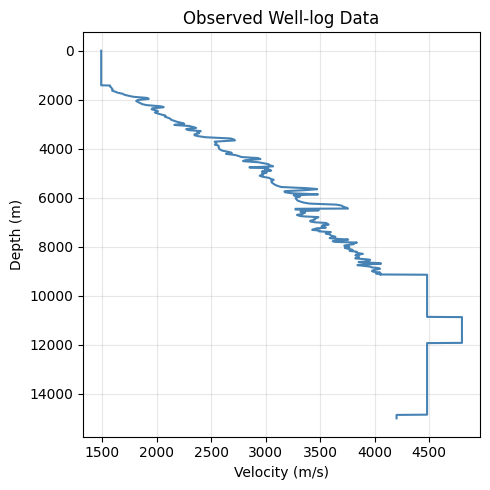

In [ ]:
# ----- Load well-log data -----
well_data   = np.loadtxt('data/Vp.Well.1')
vp_velocity = well_data[:, 1] # m/s
depth        = well_data[:, 0] # m

# ---- Plot data------------
plt.plot(vp_velocity, depth, color="steelblue")
plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel("Velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Observed Well-log Data")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print ("Velocity min: ", np.min(vp_velocity))

Velocity min:  1490.0


From the figure above, we see a clear jump at around 9, 10.1 and 12.0 km depths. At shallow depths, the velocities are also clipped to a minimum value of 1490 m/s. Both of these features do not follow our assumed polynomial relationship. Therefore, we will only consider the data above 9 km for our regression problem.

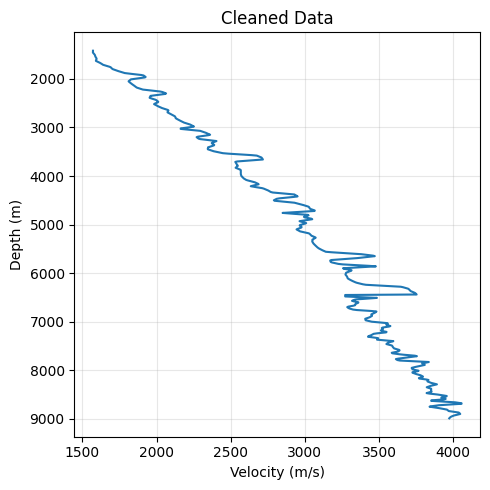

In [ ]:
#-------- Data cleaning -------------
indx_mask  = (vp_velocity > 1500) & (depth < 9000)
v_obs      = vp_velocity[indx_mask]
d_obs     = depth[indx_mask]

# --------Plot cleaned data -------------
plt.plot(v_obs, d_obs)
plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel("Velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Cleaned Data")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 2. Fit polynomials of increasing degree

We fit $V(z) \approx \sum_{i=0}^{d} c_i z^i$ for a range of degrees $d$ using `numpy.polyfit`, and based on the coefficients returned by this function, we can evaluate the polynomial at a given depth using `numpy.polyval`.

To compare the performance of the models, we will use the root mean squared error (RMSE) as a metric. The RMSE is defined as:
$$ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

where $y_i$ are the observed values and $\hat{y}_i$ are the predicted values.


RMSE for polynomial with degree 1 is: 131.7286833629056 m/s
RMSE for polynomial with degree 2 is: 90.37381093479324 m/s
RMSE for polynomial with degree 3 is: 89.05098221167694 m/s
RMSE for polynomial with degree 5 is: 85.09232879219964 m/s
RMSE for polynomial with degree 9 is: 82.76906534544776 m/s
RMSE for polynomial with degree 15 is: 77.32797003992849 m/s


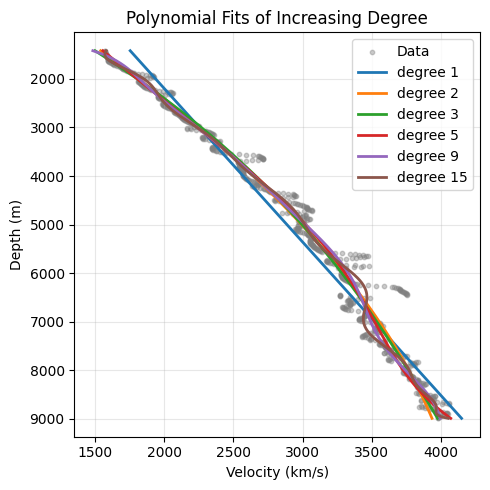

In [ ]:
degrees = [1, 2, 3, 5, 9, 15]

plt.scatter(v_obs, d_obs, s=10, alpha=0.4, color="gray", label="Data")

for d in degrees:
    coeffs = np.polyfit(d_obs, v_obs, d)
    v_fit  = np.polyval(coeffs, d_obs)

    # compute residuals between fitted velocity values and the observations
    residuals = v_obs - v_fit
    rmse = np.sqrt(np.mean(residuals**2))
    print(f'RMSE for polynomial with degree', d, 'is:', rmse, 'm/s')
    rmse = np.sqrt(np.mean(residuals**2))
    plt.plot(v_fit, d_obs, label=f"degree {d}", linewidth=2)

plt.gca().invert_yaxis()
plt.xlabel("Velocity (km/s)")
plt.ylabel("Depth (m)")
plt.title("Polynomial Fits of Increasing Degree")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The above plot suggests that a polynomial of degree 3 may be sufficient to capture the trend in the data, even though the RMSE is lower for higher degree polynomials. For a more quantitative assessment, we will split the data into train/test sets and score each degree on held-out points (test set) using RMSE. This exposes overfitting at high degree more clearly than the plot above.

### Step 3. Model selection: Polynomial degree vs RMSE tradeoff

In [ ]:
# We use the available functionality in sklearn to split the data into training and testing sets.
# We use 75% of the data for training and 25% for testing.
# The random_state parameter ensures that the split is reproducible.
z_train, z_test, v_train, v_test = train_test_split(d_obs,
                                                    v_obs,
                                                    test_size=0.25,
                                                    random_state=42)

candidate_degrees = range(1, 16)
results = {}

# Evaluate polynomial fits of different degrees and compute RMSE and R2 scores
# We store the results in a dict keyed by degree for later analysis and comparison.
for d in candidate_degrees:
    coeffs       = np.polyfit(z_train, v_train, d)
    v_pred_train = np.polyval(coeffs, z_train)
    v_pred_test  = np.polyval(coeffs, z_test)

    rmse_train = np.sqrt(mean_squared_error(v_train, v_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(v_test, v_pred_test))
    r2_test    = r2_score(v_test, v_pred_test)

    results[d] = {
        "coeffs": coeffs,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_test": r2_test,
    }

print(f"{'deg':>3} {'train RMSE':>12} {'test RMSE':>12} {'test R2':>10}")
for d, r in results.items():
    print(f"{d:>3} {r['rmse_train']:>12.4f} {r['rmse_test']:>12.4f} {r['r2_test']:>10.4f}")

deg   train RMSE    test RMSE    test R2
  1     134.3946     123.6196     0.9703
  2      93.3772      80.9136     0.9873
  3      92.2828      78.8743     0.9879
  4      88.2103      76.3292     0.9887
  5      87.9443      76.3279     0.9887
  6      86.6186      75.9782     0.9888
  7      86.0020      75.6879     0.9889
  8      85.8096      75.1341     0.9890
  9      85.3394      75.0246     0.9891
 10      83.6024      73.5868     0.9895
 11      83.4849      73.5505     0.9895
 12      83.1361      73.2381     0.9896
 13      81.5274      72.2401     0.9899
 14      80.9685      72.0751     0.9899
 15      79.0989      72.6170     0.9898


> In addition to the RMSE, we also compute the $R^2$ score, which is a measure of how well the model explains the variability in the data. This is expressed as, $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$
where $\bar{y}$ is the mean of the observed values. An $R^2$ score close to 1 indicates a good fit and a value of $0$ indicates that the model does no better than simply predicting the mean of the observed values.

Best degree by test RMSE: 14


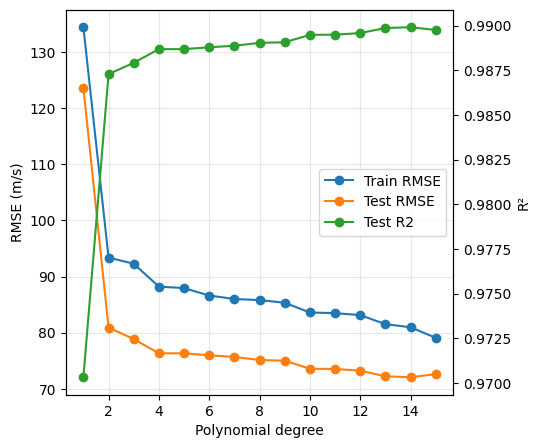

In [ ]:
# ------ Plot RMSE  for training and testing sets
degs = list(results.keys())
train_rmse = [results[d]["rmse_train"] for d in degs]
test_rmse  = [results[d]["rmse_test"] for d in degs]
test_r2    = [results[d]["r2_test"] for d in degs]

fig, ax1 = plt.subplots()

# RMSE on the left axis
l1, = ax1.plot(degs, train_rmse, "o-", color="tab:blue", label="Train RMSE")
l2, = ax1.plot(degs, test_rmse, "o-", color="tab:orange", label="Test RMSE")
ax1.set_xlabel("Polynomial degree")
ax1.set_ylabel("RMSE (m/s)")
ax1.grid(alpha=0.3)

# R2 on the right axis
ax2 = ax1.twinx()
l3, = ax2.plot(degs, test_r2, "o-", color="tab:green", label="Test R2")
ax2.set_ylabel("R²")

# Combine legends from both axes
lines = [l1, l2, l3]
ax1.legend(lines, [l.get_label() for l in lines], loc="center right")

best_degree = min(results, key=lambda d: results[d]["rmse_test"])
print(f"Best degree by test RMSE: {best_degree}")

> The figure above shows that the RMSE decreases with increasing polynomial degrees (although slowly) until degree 14 and then increases again. This trend demonstrates one of the fundamental trade-offs in regression problems: **bias and variance**. We discuss this trade-off in the following section.

##### Bias and Variance

- **Bias** is error from a model that is *too simple* to capture the true pattern. For example, a degree 1 polynomial (a straight line) in our case would not be able to capture the velocity-depth curve observed in the data, leading to high bias. A model with high bias underfits even with more data because the model is not flexible enough to capture the underlying relationship.

- **Variance** is error from a model that is *too complex* and specific to the training data. For example, a degree-15 polynomial would not only fit the velocity-depth relationship, but also the the noise that may be specific only to the training dataset. Such a model would likely perform poorly on new, unseen data because it has learned the noise in the training set rather than the underlying relationship. A model with high variance overfits the training data and does not generalize well.

### Step 4. Predict velocities at new depths
We choose the final model as degree 4 polynomial as the RMSE drops significantly until then and from degree 4 to degree 14, we do not gain substantial improvement in the RMSE while adding 10 more parameters to predict seismic velocities at new depths.

The predicted values can be obtained by evaluating the polynomial at the desired depths using `numpy.polyval`.

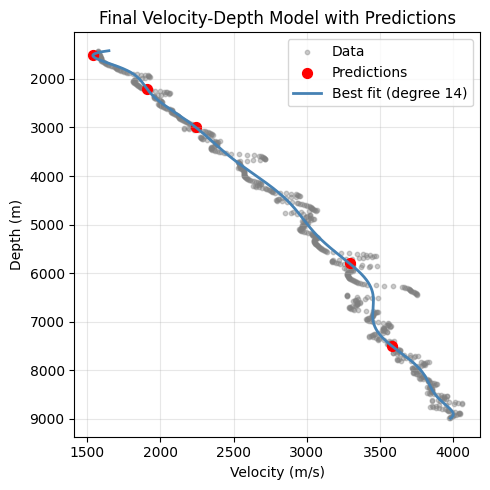

In [ ]:
coeffs_best = results[best_degree]["coeffs"]

# Predict at some depths of interest
query_depths = np.array([1500, 2200, 3000, 5800, 7500])
predicted_v = np.polyval(coeffs_best, query_depths)

#-----Plot the predictions and the final fit
plt.scatter(v_obs, d_obs, s=10, alpha=0.4, color="gray", label="Data")
plt.scatter(predicted_v, query_depths, s=50, color="red", label="Predictions")
plt.plot(np.polyval(coeffs_best, d_obs), d_obs, color="steelblue", label=f"Best fit (degree {best_degree})", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Final Velocity-Depth Model with Predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> From the figure above, you can see that the polynomial deviates the most at the sharp seismic discontinuities, as it is smooth representation of the data. To overcome this, we can use piecewise polynomial regression, which fits separate polynomials to different segments of the data. This allows for better modeling of abrupt changes in the relationship between depth and seismic velocity.

### Try it yourself

- What happens if you predict velocities at depths outside of the range of the training data? Use `query_depths = np.array([1000, 1200, 1500])` in the above cell? How does the model behave, and what does this tell you about polynomial regression?
- Try fitting this model to well data Vp.Well.2. Does the same degree polynomial work well for this new dataset? What does this tell you about the physical relationship?

#### References

- Wang, S. Y., & Wang, H. Y. (2016). Site-dependent shear-wave velocity equations versus depth in California and Japan. Soil Dynamics and Earthquake Engineering, [88, 8-14](https://www.sciencedirect.com/science/article/pii/S0267726116300367).
- Data availble by 2013 SEG Advanced Modeling Corporation, SEAM Open Data and downloaded from [SEG open data sets](https://wiki.seg.org/wiki/SEAM_Phase_I:_Interpretation_challenge_I_-_Depth)

 &nbsp;<div style="text-align: right">  
    &rarr; <b>NEXT: [Thermodynamic parameter estimation using random forest](./3_random_forest.ipynb) </b> <a href=""></a> &nbsp;&nbsp;
     <img src="../../../assets/education-gem-notebooks_icon.png" alt="icon"  style="width:4%">
  </div>